## Title: Data Visualization Notebook - Sensitivity Analysis

#### Author: Nilay Kumar
Multicellular Systems Engineering Lab

### Update Author: Stephen Cini
Dowling Lab

Department of Chemical and Biomolecular Engineering

University of Notre Dame

#### Summary
This notebook is used for visualizing the data generated by `master_sensitivity_analysis.py`. The data plotted here corresponds to Figure 2C of the manuscript.

In [ ]:
# Adding dependencies folder to the path. Dependencies stores all teh classes used in bayesian optimization BO
import sys
sys.path.append("/Users/scini/Documents/GitHub/ReverseEngineeringMorphogenesis/emulatorGPBO_update_StephenCini2026")
# Loading in libraries
import pandas as pd
import matplotlib.pyplot as plt
import spatial_efd
import math 
import signac
import numpy as np
import os.path
import os
import torch
import gpytorch
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import similaritymeasures
#from smt.sampling_methods import LHS
# Importing helper libraries for bayesian optimization
from dependencies.data_preprocessing_class import DataPreprocessing
from dependencies.gaussian_process_regression_class import GaussianProcessRegression
from dependencies.acquisition_functions_class import AcqisitionFunctions
from dependencies.geometry_writer import GeometryWriter
from dependencies.feature_extractor_4 import FeatureExtractor

#### 1. Sensitivity Simulations and Parameter Variation

For the computation of sensitivity, simulations are run by increasing and decreasing parameter values by 70%. For each simulation run, the following data are recorded:

1. Edge length of individual components. shape: 
2. Local curvature estimated at each vertex on the basal surface
3. Frechet error measuring deviation of apical and basal surface from the equilibrium tissue shape

Parameters varied:
- '$T^{squ}_{B}$',`'$T^{cub}_{B}$', '$T^{col}_{B}$'
- '$k^{squ}_{A}$', '$k^{squ}_{B}$', '$k^{squ}_{L}$', '$k^{cub}_{A}$', '$k^{cub}_{B}$', '$k^{cub}_{L}$', '$k^{col}_{A}$', '$k^{col}_{B}$', '$k^{col}_{L}$', '$Lo^{squ}_{A}$'
- '$Lo^{squ}_{B}$', '$Lo^{squ}_{L}$', '$Lo^{cub}_{A}$', '$Lo^{cub}_{B}$', '$Lo^{cub}_{L}$', '$Lo^{col}_{A}$', '$Lo^{col}_{B}$', '$Lo^{col}_{L}$'
- '$K_{ECM}$'

#### 2. Measured Morphological Changes

In this section, we perform the following steps to analyze the data:

1. Convert edge length matrix into meaningful measurable wing disc cell lengths.
2. Split curvature to approximate the curvature of the basal surface adhering to the columnar cells.
3. Load the Frechet error for approximation the error of the apical and basal surfaces from the base shape.

In [2]:
"""  Step 1: Transforming the cell lengths
Inputs:
     i) tissue_edge_length_master: edge lengths of all the cells for samples from parameter screen. It is a 
                                   [n_samples x 390] array; n_samples = 2*num_parametsr_varied
     ii) edge_length_identity: Each of the 390 edge lengths belong to a specific cell type class. The array 
                               contains 390 labels for each edge type
Output: 
     i) tissue_edge_length_t : The edge lengths are trucated as mean values of edge lengths belonging to a 
                               particular calss of cell type. Its a n_samples x 11 array. We have a total of 
                               11 different edge ypes  """

# Defining the total number of simulations
n_simulation = 44 # Twice the number of parameters whose sensitivity is being computed
# Reading the excel sheet containiing identity of all the 390 cell types
df_identity = pd.read_excel ('input_data/edge_length_identity.xlsx')
# Loading the master data containing edge lengths in columns (390) for all the samples in row
tissue_edge_length_master = np.load('output_data_files/tissue_edge_length_master.npy')
# Labels for individual ege length types
edge_length_labels = ('$L^{col}_{A}$', '$L^{col}_{B}$', '$L^{col}_{L}$', '$L^{cub}_{A}$', '$L^{cub}_{B}$', '$L^{cub, col}$', '$L^{cub}_{L}$', '$L^{squ}_{A}$', '$L^{squ}_{B}$', '$L^{squ, cub}$', '$L^{squ}_{L}$')         
# Initializing truncated edge length array
tissue_edge_length_t = np.zeros((n_simulation,11))
# Iterating through each sample to truncate the edge lengths
for i in range(n_simulation):
    # edge length for the nth sample
    iter_edge_length = tissue_edge_length_master[i,:]
    # reshaping the array as a column array for truncation
    iter_edge_length_r = np.reshape(iter_edge_length,(390,1))
    # creating two data frames of edge lengths and their identities
    df_edge_length = pd.DataFrame(iter_edge_length_r, columns = ['SE_edge_length'])
    df_iter = pd.concat([df_identity, df_edge_length], axis=1)
    # Use the grouping feature of dataframes to compute mean edge length for each cell type
    x = df_iter.groupby('identity').mean().values
    # Storing the truncated values in master truncated edge length rray
    tissue_edge_length_t[i,:] = np.reshape(x,(1,11))

"""  Step 2: Tranforming the curvature
Inputs: 
    i) curvature_basal_master: An array of shape [n_samples x n_curv_points] containing local curvature of the basal epithelia
Outputs: 
    ii) curvature_basal_t :  Average basal curvature for columnar tissue computed at the medial and lateral ends.
                             Shape - [n_samples x 3] """

# Loading the array containing curvature data from the sensitivity screening
curvature_basal_master = np.load('output_data_files/curvature_basal_master.npy')
# Extracting the curvature of the bsala columnar epithelia
curvature_basal_master_columnar = curvature_basal_master[:,16:116]
# Initializing the array theat will store the truncated average curvature within the basal epithelia
curvature_basal_t = np.zeros((n_simulation,3))
# Extracting curvature values of three equal domains representing the medial basal and two mlateral basal domains
curv_right = curvature_basal_master_columnar[:,0:25]
curv_center = curvature_basal_master_columnar[:,25:75]
curv_left = curvature_basal_master_columnar[:,75:100]
# Computing average curvature values for the three domains
curv_right_average = np.mean(curv_right, axis = 1)
curv_center_average = np.mean(curv_center, axis = 1)
curv_left_average = np.mean(curv_left, axis = 1)
# Storing the truncated currvatures in masater array
curvature_basal_t[:,0] = curv_right_average 
curvature_basal_t[:,1] = curv_center_average
curvature_basal_t[:,2] = curv_left_average


"""  Step 3: Loading frechet error for upper and lower parameter bounds  """

error_target_sampled_apical = np.load('output_data_files/error_target_sampled_apical.npy')
error_target_sampled_basal = np.load('output_data_files/error_target_sampled_basal.npy')

#### 3. Computing sensitivities for different features

1. Central difference scheme was used to compute sensitivities: $ S_P = \frac{F_{P + \delta_{P}} - F_{P - \delta_{P}}}{2\delta_{P}} $ where,
    - $S_P$ denotes the sensitivity of a particular parameter P
    - $ \delta_{P} $ represents samll perturbation in the parameter value (70%)
    - $ F $ represents the value of a particular feature say height or frechet error for the parameter value P.


2. Different geometric features whose changes were measured on variation of parameters:
    - Frechet error for apical surface, number of features: 1
    - Frechet error for thr basal surface, number of features: 1
    - Truncated cell lengths (columnar only, number of features: 11)
    - Truncated basal curvatures, number of features: 3

In [3]:
"""
This portion of the code computes sensitivitiy in shape features upon variation of model parameters using
the finite difference formulae. 

Sensitivity can be compued using two different ways based on the choice of calc_method parameter.
calc_method == 1 : Actual change in parameter values is used
calc_method == 2 : Percentage change in parameter value is used (0.7)

"""
calc_method = 3
# number of parameters varied
n_param = 22
# param values around equilibrium
val_param = [0,3.162277660168379e-08,0,0,3.162277660168379e-08,0,0,1e-05,0,0,0, 0.1,0.1,10,0.1,0.1,0.1,0.01, 3.9810717055349695e-05, 0.01,0.001,0.001, 1,1,0.6,0.6,0.6,0.6,0.2,0.1,3,0.6,1.8, 0.002511886431509582,0.001]
# Initialization of arrays to store sensitivities in features upon perturbation of parameters
sens_frechet_apical = np.zeros((n_param,))
sens_frechet_basal = np.zeros((n_param,))
sens_curv = np.zeros((n_param,3))
sens_cell_length = np.zeros((n_param,11))

# Calculating sensitivities for different parameters using the formulae above
for i in range(n_param):
    # Defining choice of sensitivity calculation
    if calc_method == 1:
        d_theta = 0.7*param_val[i]
    elif calc_method == 2:
        d_theta = 0.7
    elif calc_method == 3:
        d_theta = np.log(1.7)
    # For each parameter i, the 2*ith entry holds the data for lower bound of parametsr and 2*i-1 holds the data for the
    # upper bound of parameter. This is used to compute the numerator of the finite difference approximation of sensitivity
    sens_frechet_apical[i] = (error_target_sampled_apical[2*i + 1] - error_target_sampled_apical[2*i]) / (2*d_theta)
    sens_frechet_basal[i] = (error_target_sampled_basal[2*i + 1] - error_target_sampled_basal[2*i]) / (2*d_theta)
    sens_curv[i,:] = np.subtract(curvature_basal_t[2*i+1,:], curvature_basal_t[2*i,:]) / (2*d_theta)
    sens_cell_length[i,:] = np.subtract(tissue_edge_length_t[2*i+1,:], tissue_edge_length_t[2*i,:]) / (2*d_theta)

<>:36: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:43: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:50: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:77: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:36: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:43: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:50: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences wil

Text(0.5, 0.95, '$f$')

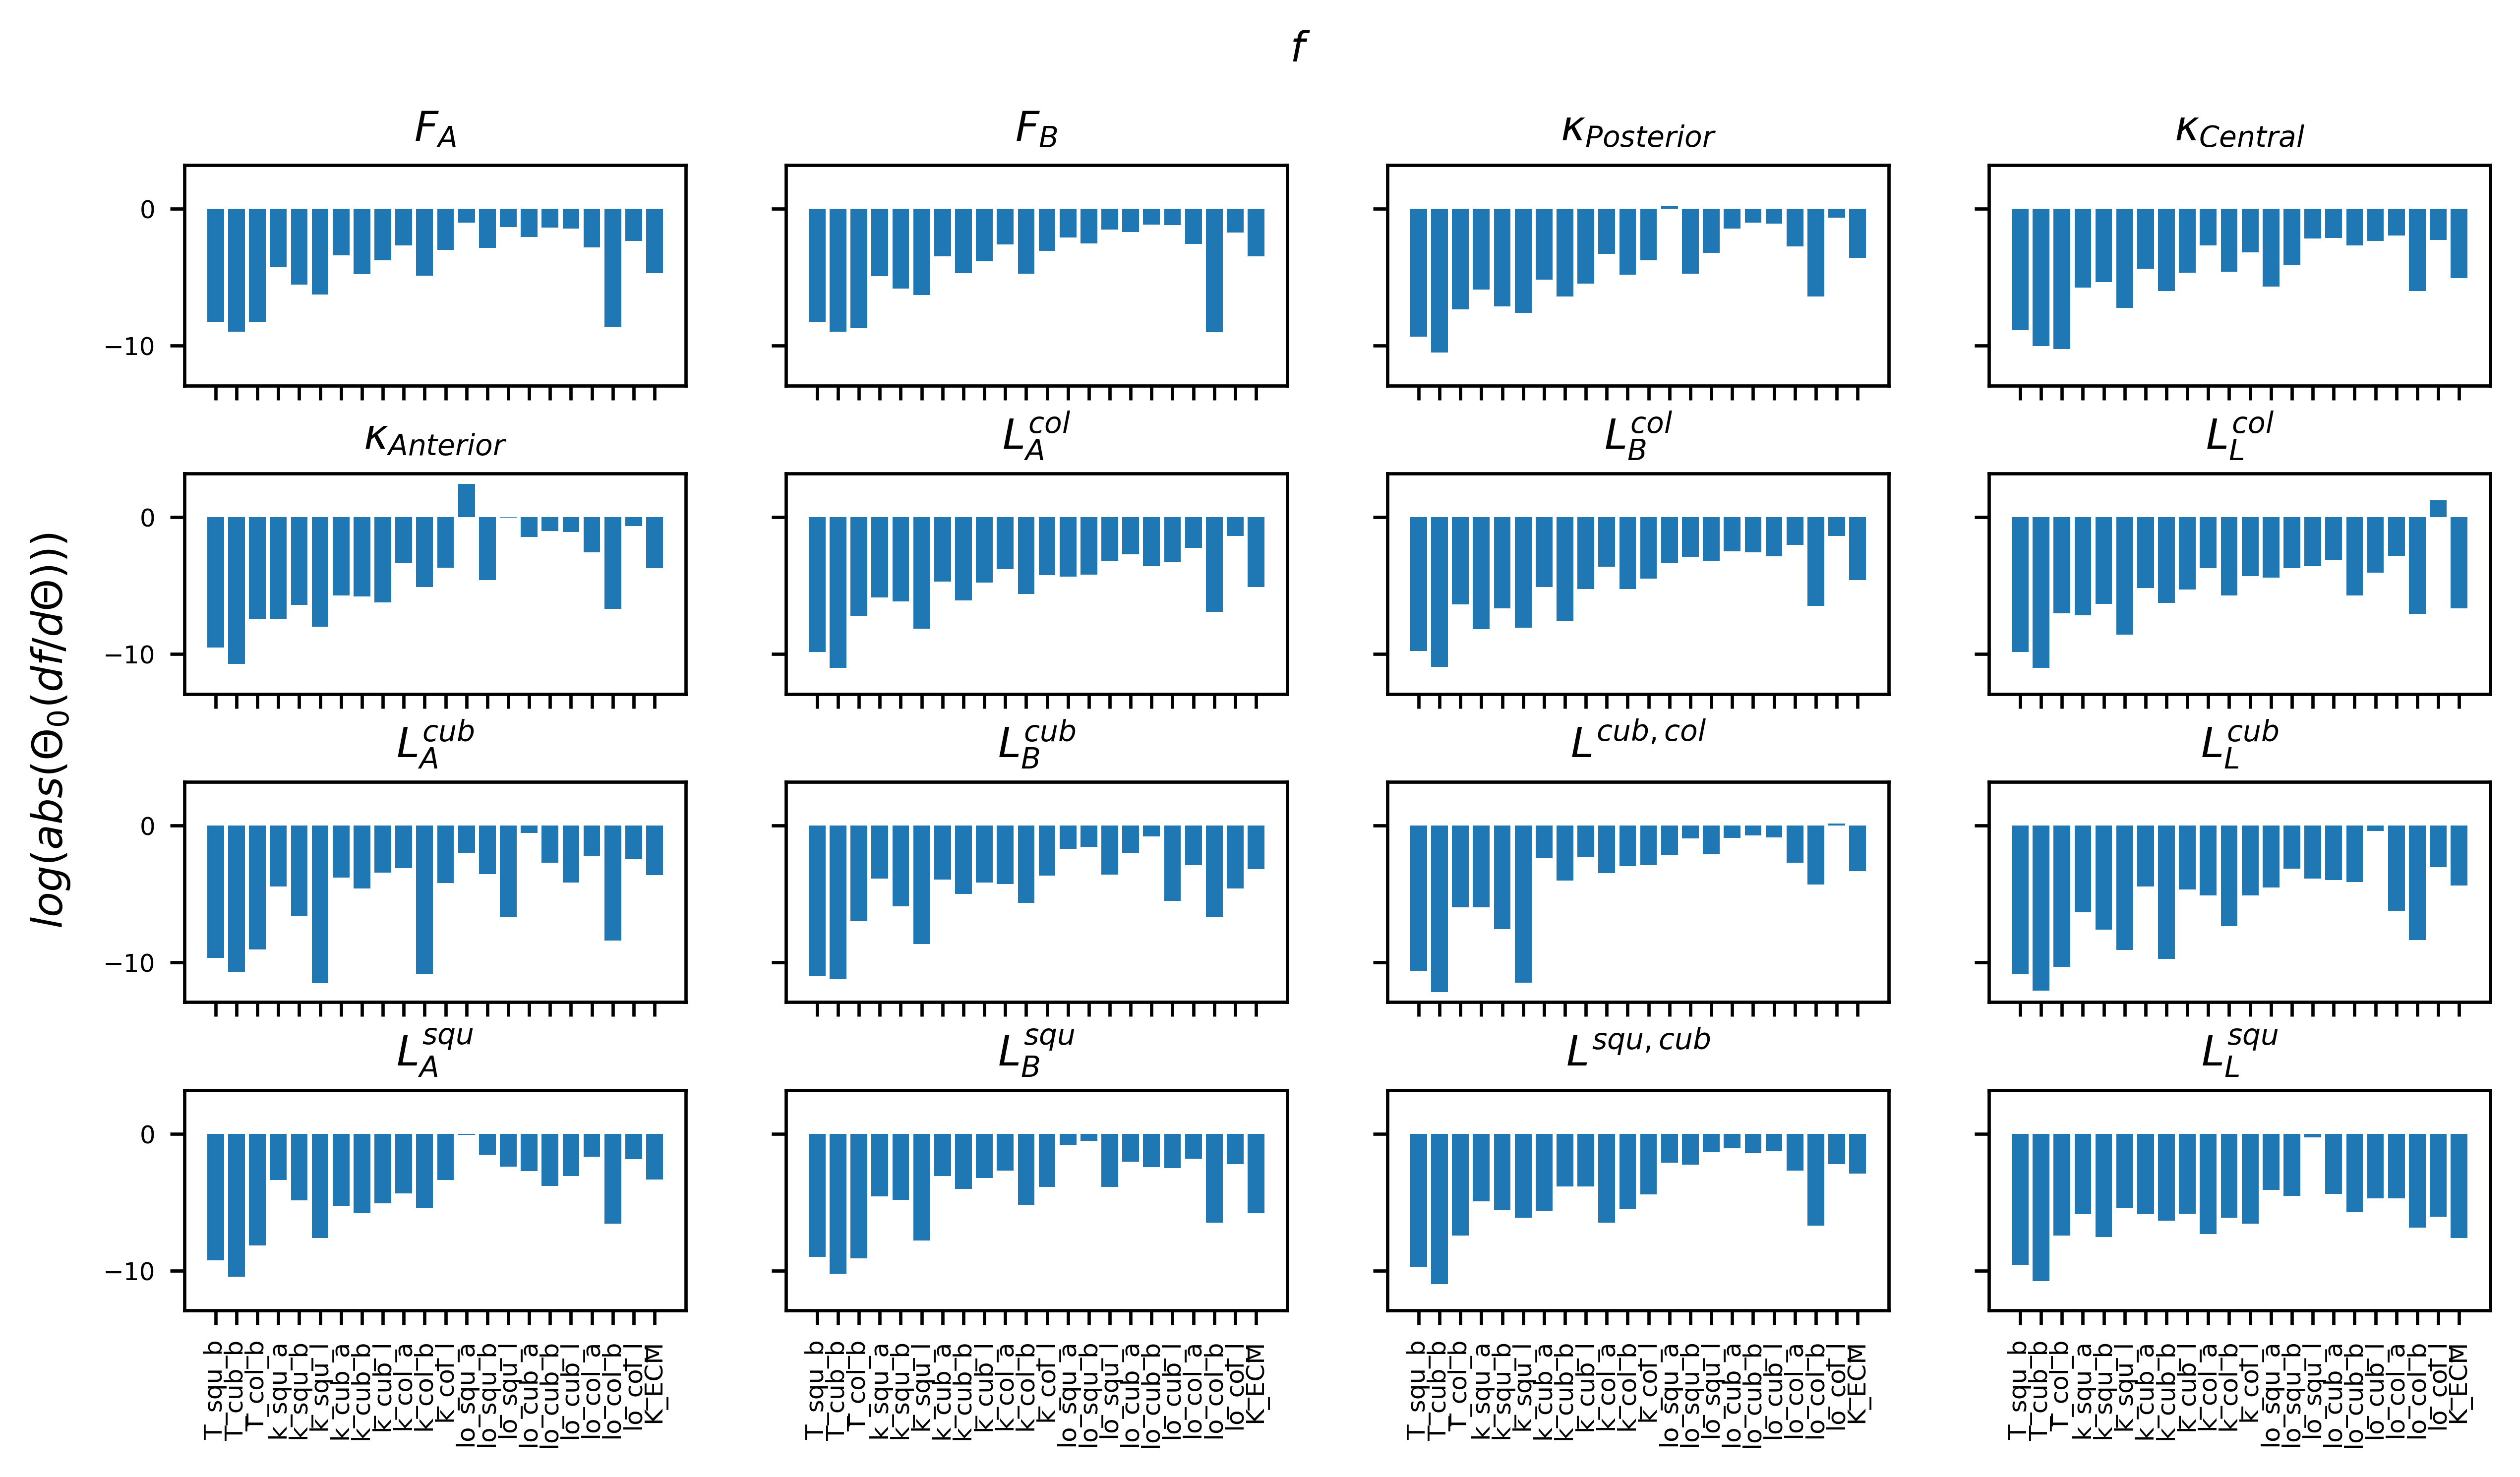

In [4]:
# List of parameters in the sampling for screening    
params_lhs = ('T_squ_b','T_cub_b','T_col_b','k_squ_a','k_squ_b','k_squ_l','k_cub_a','k_cub_b','k_cub_l','k_col_a','k_col_b','k_col_l','lo_squ_a','lo_squ_b','lo_squ_l','lo_cub_a','lo_cub_b','lo_cub_l','lo_col_a','lo_col_b','lo_col_l','K_ECM')
# Defining the size (figsize) and resolution (dpi) of figure
fig, ax = plt.subplots(nrows=4, ncols=4, sharex=True, sharey=True, figsize=(10, 5), dpi=600)

"""  Step 1: Plotting sensitivity in Frechet errors  """

# Positioning the bars at equal intervals. Number of bars for each subplot
# equals the number of parameters that were varied.
y_pos = np.arange(len(params_lhs))
# Subplot 1: Sensitivity in apical frechet error
plt.subplot(4, 4, 1)
# Using matplotlib to plot sensitivities for frechet error apical in define positions on the x axis
plt.bar(y_pos, np.log(np.abs(sens_frechet_apical)))
# Turing off ticks in the scale
plt.xticks([])
# Changing the fontsize of y axis
plt.yticks(fontsize=6)
# Defining title of the plot representing the feature for which sensitivityt was measured
plt.title('$F_{A}$', fontsize=10)
# Subplot 1: Sensitivity in basal frechet error
plt.subplot(4, 4, 2)
plt.bar(y_pos, np.log(np.abs(sens_frechet_basal)))
plt.xticks(y_pos, params_lhs)
plt.xticks([])
plt.yticks(fontsize=6)
plt.title('$F_{B}$', fontsize=10)

"""  Step 2: Plotting sensitivity in curvatures  """

# Subplot 3
plt.subplot(4, 4, 3)
plt.bar(y_pos, np.log(np.abs(sens_curv[:,0])))
plt.xticks([])
plt.yticks(fontsize=6)
plt.title('$\kappa_{Posterior}$', fontsize=10)
# Subplot 4
plt.subplot(4, 4, 4)
plt.bar(y_pos, np.log(np.abs(sens_curv[:,1])))
plt.xticks(y_pos, params_lhs)
plt.xticks([])
plt.yticks(fontsize=6)
plt.title('$\kappa_{Central}$',fontsize=10)
# Subplot 5
plt.subplot(4, 4, 5)
plt.bar(y_pos, np.log(np.abs(sens_curv[:,2])))
plt.xticks(y_pos, params_lhs)
plt.xticks([])
plt.yticks(fontsize=6)
plt.title('$\kappa_{Anterior}$',fontsize=10)

"""  Step 3: Plotting sensitivity in cell height  """

for i in range(11):
    if i < 7:
        plt.subplot(4, 4, 5+i+1)
        plt.bar(y_pos, np.log(np.abs(sens_cell_length[:,i])))
        plt.xticks([])
        plt.yticks(fontsize=6)
        plt.title(edge_length_labels[i], fontsize=10)
    # Printing x labels in the bar plots of last row
    elif i >= 7:
        plt.subplot(4, 4, 5+i+1)
        plt.bar(y_pos, np.log(np.abs(sens_cell_length[:,i])))
        plt.xticks(y_pos, params_lhs)
        plt.xticks(rotation = 90)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=6)
        plt.title(edge_length_labels[i], fontsize=10)
    

"""  Final figure adjustments  """

# Making the spaces between the subplots uniform
plt.subplots_adjust(hspace=0.4)
# Deining the label of y axis for all the sublots. Placing it in the left hand side of the figure.
fig.text(0.073, 0.5, '$log(abs(\Theta_{0}(df/d\Theta)))$', va='center', rotation='vertical')
fig.text(0.5, 0.95, '$f$', ha='center')

__Figure 1: Barplots describing sensitivities of all the measured geometrical features upon perturbation of model parameters.__  A total of 16 geometrical features whose sensitivity is measures are listed as heading of each subplot. Labels in the x axis of each plot represent the model parameters that were varied against which the sensitivity was cmputed.*Note: Log of absolute value of sensitivity has been plotted*

<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:20: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:24: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences wil

Text(0.5, -28.200000000000053, '$Output - f$')

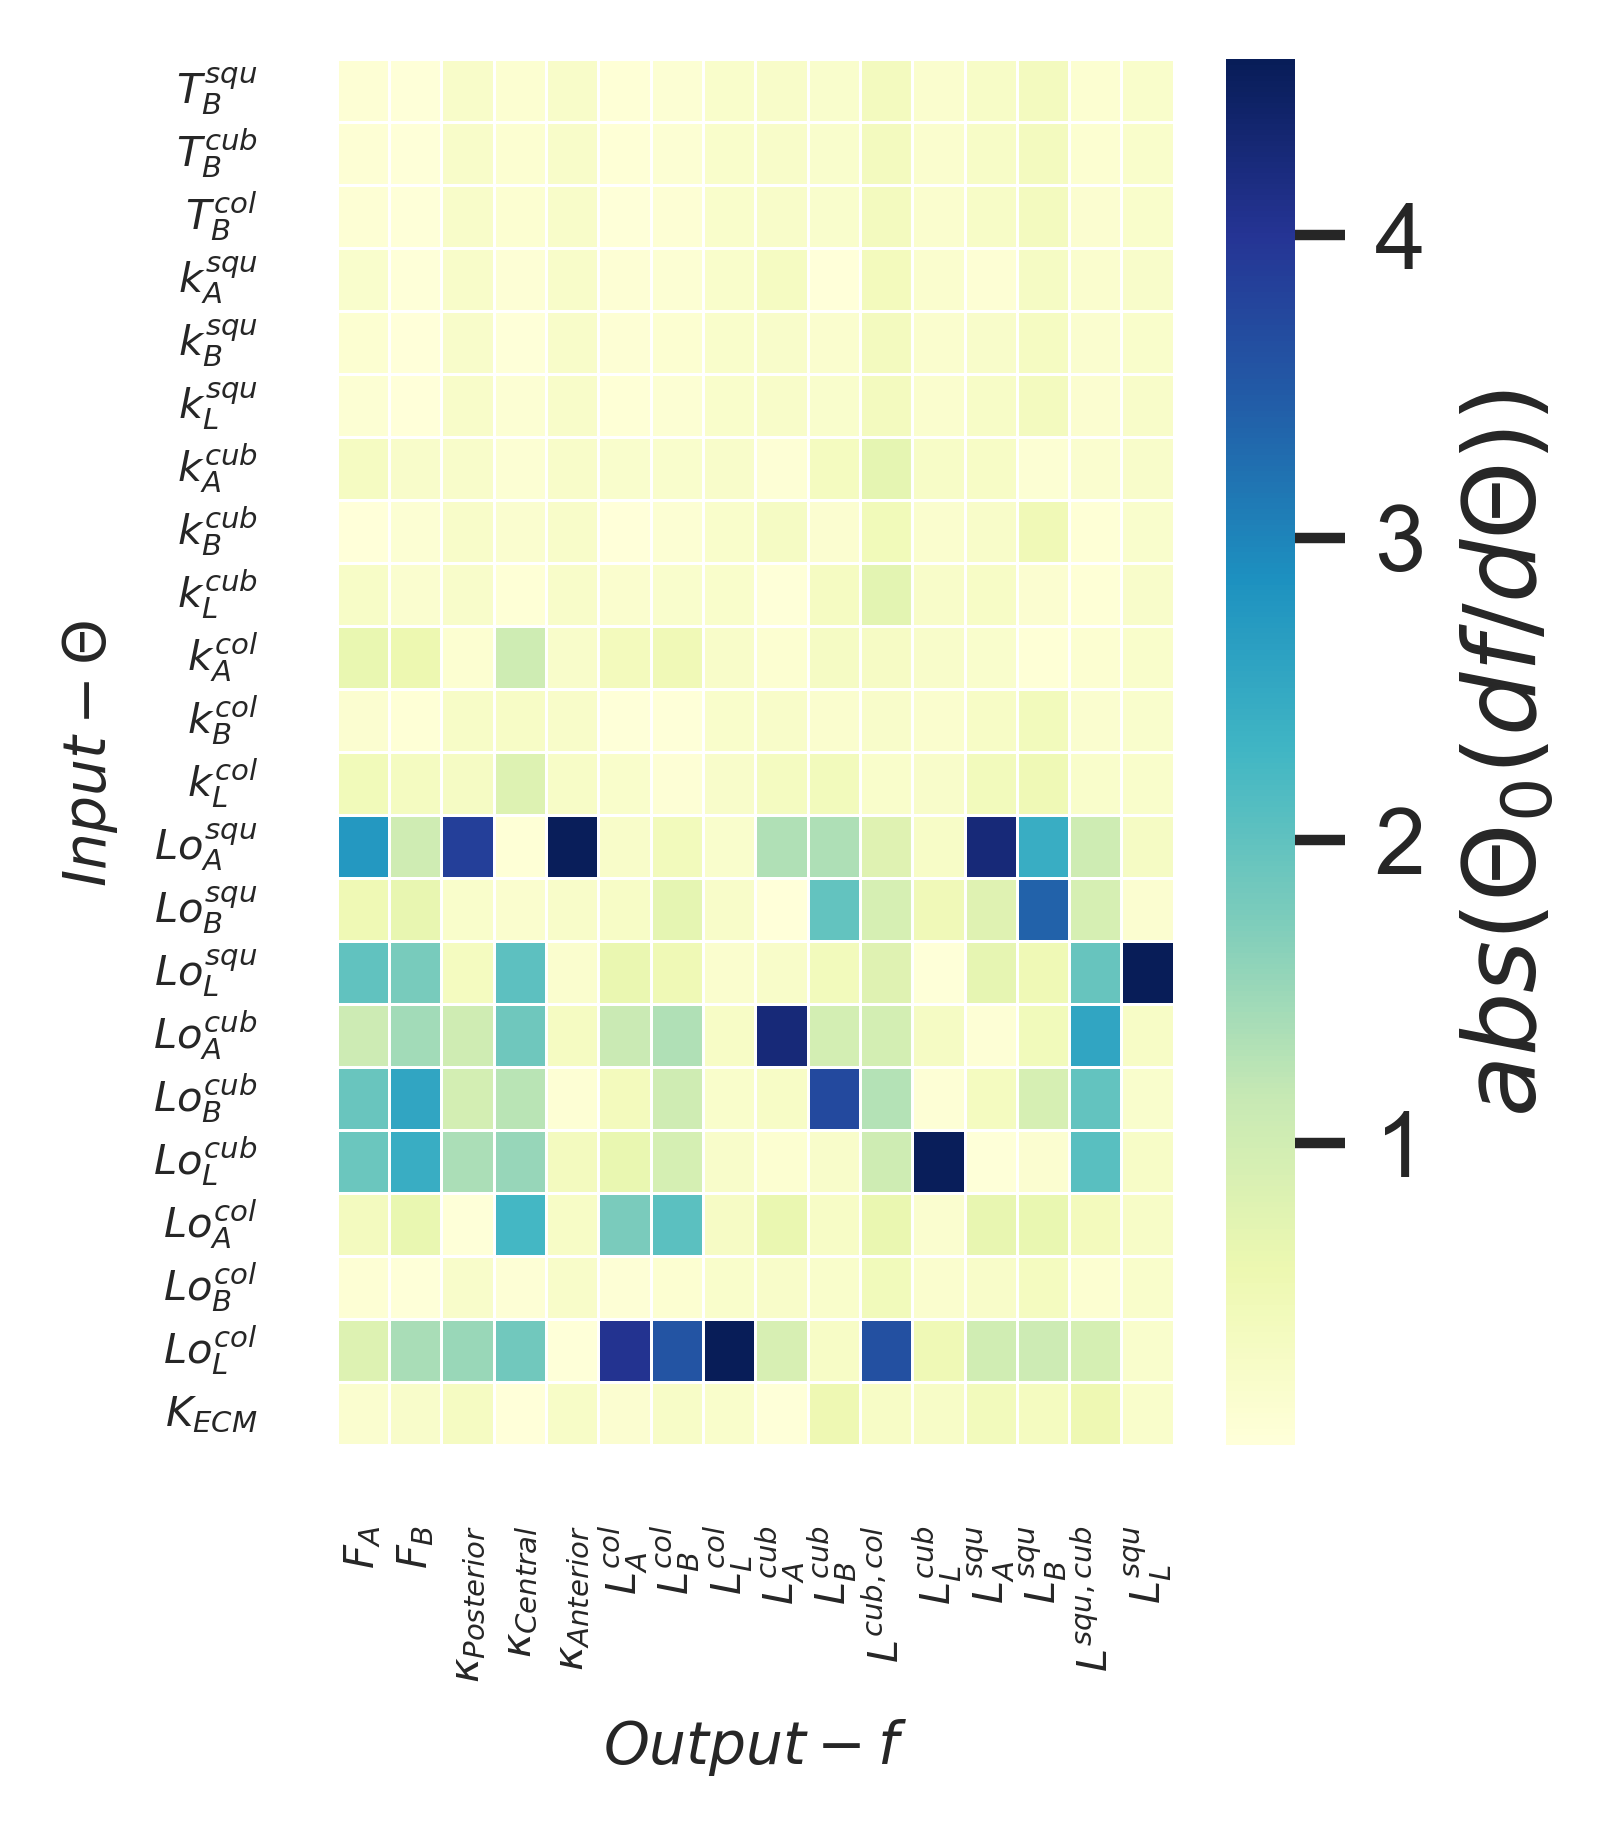

In [5]:
# Creating the master sensitivity matrix by horizontally concatenating each column representing a particular geometrical feature .
sens_master = np.hstack((np.reshape(sens_frechet_apical,(22,1)),np.reshape(sens_frechet_basal,(22,1)),sens_curv, sens_cell_length))
# Scaling the sensitivity wrt to mean 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sens_master_scaled = sc.fit_transform(sens_master)

""" Plotting """

# Importing seaborn for visualization of the sensitivity array
import seaborn as sns
# Defining labels of features and parameters
x_label = ('$F_{A}$','$F_{B}$')+('$\kappa_{Posterior}$','$\kappa_{Central}$','$\kappa_{Anterior}$')+ edge_length_labels
params_lhs = ('$T^{squ}_{B}$','$T^{cub}_{B}$','$T^{col}_{B}$','$k^{squ}_{A}$','$k^{squ}_{B}$','$k^{squ}_{L}$','$k^{cub}_{A}$','$k^{cub}_{B}$','$k^{cub}_{L}$','$k^{col}_{A}$','$k^{col}_{B}$','$k^{col}_{L}$','$Lo^{squ}_{A}$','$Lo^{squ}_{B}$','$Lo^{squ}_{L}$','$Lo^{cub}_{A}$','$Lo^{cub}_{B}$','$Lo^{cub}_{L}$','$Lo^{col}_{A}$','$Lo^{col}_{B}$','$Lo^{col}_{L}$','$K_{ECM}$')
# Defining the resolution of the figure
sns.set(rc={"figure.dpi":600, 'savefig.dpi':600})
# Defining the size of figure
sns.set(rc={'figure.figsize':(2.25,3)})
# Using seaborn to plot visualize the array as a heatmap
ax = sns.heatmap(np.abs(sens_master_scaled), xticklabels = x_label, yticklabels = params_lhs, linewidths=.3, cmap="YlGnBu", cbar_kws={'label': '$abs(\Theta_{0}(df/d\Theta))$'})
# Labelling the axes
ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize = 5)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 5)
ax.set_ylabel('$Input - \Theta$', fontsize=7)
ax.set_xlabel('$Output - f$', fontsize=7)

__Figure 2: Plotting heatmaps of sensitivities.__ *Notes: __(A)__ A master sensitivity array is defined where evry column represents sensitivity in a particular feature (row). Each row     represents the total parameters that were varied during the sensitivity analysis. Shape [n_param x n_feature] __(B)__ Scaled and non-scaled senitivities are plotted*